In [1]:
import pandas as pd
import seaborn as sb
import math
import numpy as np
import matplotlib.pyplot as plt

d = pd.read_excel("modelling_data.xlsx")

##ed = pd.read_excel("evaluation_data.xlsx")

Xm = d
#Xe = ed.drop(['ROW_ID','claimcount'], axis = 1)
#Ye = ed['claimcount']

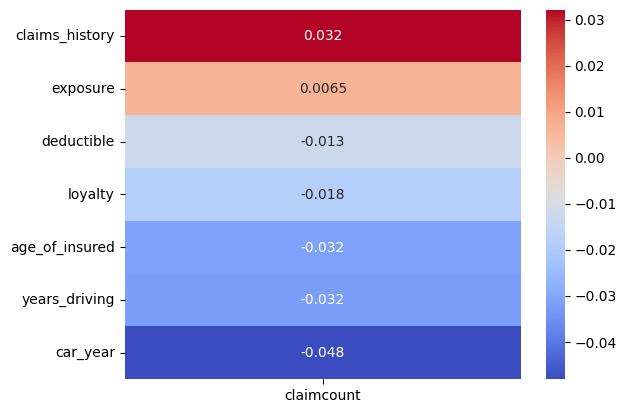

In [2]:
corrholder = Xm
corr = corrholder.corr(numeric_only=True).sort_values(by='claimcount', ascending=False)
corr2 = corr.drop('claimcount')
sb.heatmap(corr2[['claimcount']], cmap='coolwarm', annot=True)
plt.show()

In [3]:
x_ord = ['annual_mileage','annual_income','credit_band', 'vehicle_value']
x_bin = ['gender', 'winter_tires']
x_one_hot = ['location', 'ownership', 'occupation', 'marital_status', 'car_model']

am_r = ['0-5000', '5000-10000', '10000-15000', '15000-20000', '20000-25000']
ai_r = ['0-10000', '10000-30000', '30000-50000','50000-75000', '75000-100000', '100000-150000', '150000-1000000']
cb_r = ['K', 'I', 'J', 'F', 'E', 'D', 'C', 'B', 'A', 'AA', 'AAA']
vv_r = ['0-5000', '5000-10000', '10000-15000', '15000-20000', '20000-25000', '25000-30000', '30000-50000', '50000-75000', '75000-100000']

g_r = ['Male', 'Female']
wt_r = ['Yes', 'No']

l_r = ['Mississauga', 'Oakville','Toronto', 'Burlington', 'Hamilton', 'Brampton']
ow_r = ['financed', 'leased', 'owned']
oc_r = ['Military', 'Farming', 'Government', 'Healthcare', 'Businessowner', 'Unemployed', 'Trades', 'Industrial', 'Office', 'Education', 'Retail']
ms_r = ['Widowed', 'Seperated', 'Single', 'Married'] 
cm_r = ['Kia', 'Jeep', 'Hyundai', 'Cadillac', 'Volvo', 'Dodge', 'Ford', 'Nissan', 'Audi', 'Subaru', 'BMW', 'Toyota', 'Mercedes', 'Honda']

#print(Xm.head())

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
cb_h = OrdinalEncoder(categories=[cb_r], handle_unknown='use_encoded_value', unknown_value=-1)
cb_h2 = cb_h.fit_transform(Xm[['credit_band']])
cb_df = pd.DataFrame(cb_h2, columns=cb_h.get_feature_names_out())
am_h = OrdinalEncoder(categories=[am_r], handle_unknown='use_encoded_value', unknown_value=-1)
am_h2 = am_h.fit_transform(Xm[['annual_mileage']])
am_df = pd.DataFrame(am_h2, columns=am_h.get_feature_names_out())
ai_h = OrdinalEncoder(categories=[ai_r], handle_unknown='use_encoded_value', unknown_value=-1)
ai_h2 = ai_h.fit_transform(Xm[['annual_income']])
ai_df = pd.DataFrame(ai_h2, columns=ai_h.get_feature_names_out())
vv_h = OrdinalEncoder(categories=[vv_r], handle_unknown='use_encoded_value', unknown_value=-1)
vv_h2 = vv_h.fit_transform(Xm[['vehicle_value']])
vv_df = pd.DataFrame(vv_h2, columns=vv_h.get_feature_names_out())

g_h = OrdinalEncoder(categories=[g_r], handle_unknown='use_encoded_value', unknown_value= -1)
g_h2 = g_h.fit_transform(Xm[['gender']])
g_df = pd.DataFrame(g_h2, columns=g_h.get_feature_names_out())
wt_h = OrdinalEncoder(categories=[wt_r], handle_unknown='use_encoded_value', unknown_value= -1)
wt_h2 = wt_h.fit_transform(Xm[['winter_tires']])
wt_df = pd.DataFrame(wt_h2, columns=wt_h.get_feature_names_out())

l_h = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
l_h2 = l_h.fit_transform(Xm[['location']])
l_df = pd.DataFrame(l_h2, columns=l_h.get_feature_names_out())
ow_h = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ow_h2 = ow_h.fit_transform(Xm[['ownership']])
ow_df = pd.DataFrame(ow_h2, columns=ow_h.get_feature_names_out())
oc_h = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
oc_h2 = oc_h.fit_transform(Xm[['occupation']])
oc_df = pd.DataFrame(oc_h2, columns=oc_h.get_feature_names_out())
ms_h = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ms_h2 = ms_h.fit_transform(Xm[['marital_status']])
ms_df = pd.DataFrame(ms_h2, columns=ms_h.get_feature_names_out())
cm_h = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
cm_h2 = cm_h.fit_transform(Xm[['car_model']])
cm_df = pd.DataFrame(cm_h2, columns=cm_h.get_feature_names_out())

Xm_n = Xm.drop(['annual_mileage', 'winter_tires', 'gender', 'annual_income', 'credit_band', 'vehicle_value', 'location', 'ownership', 'occupation', 'marital_status', 'car_model'], axis = 1)

Xm2 = pd.concat([Xm_n, cb_df, am_df, ai_df, vv_df, g_df, wt_df, l_df, ow_df, oc_df, ms_df, cm_df], axis=1)

In [4]:
Xm2.head(10)

,deductible,claims_history,years_driving,loyalty,age_of_insured,car_year,exposure,claimcount,credit_band,annual_mileage,...,car_model_Ford,car_model_Honda,car_model_Hyundai,car_model_Jeep,car_model_Kia,car_model_Mercedes,car_model_Nissan,car_model_Subaru,car_model_Toyota,car_model_Volvo
0,2000,0,18,2,40,2024,0.663020,0,10.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1000,0,28,4,46,2024,0.294235,0,10.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1500,0,23,13,44,2015,0.617784,0,10.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1500,0,22,7,42,2013,0.560516,0,9.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1000,0,30,13,48,2016,0.193881,0,10.0,2.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1500,0,18,5,37,2024,0.650545,0,10.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,2000,0,28,9,47,2021,0.779107,0,9.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,2000,0,22,11,40,2012,0.111248,0,10.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1000,0,17,5,35,2017,0.647513,0,10.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1500,0,20,6,38,2020,0.543066,0,9.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def calculate_vif(X):
    X = X.copy()

    # Keep only numeric columns
    X = X.select_dtypes(include=["number"])

    # Remove constant columns
    X = X.loc[:, X.nunique() > 1]

    # Add intercept
    X_const = add_constant(X)

    vif_df = pd.DataFrame({
        "feature": X_const.columns,
        "vif": [
            variance_inflation_factor(X_const.values, i)
            for i in range(X_const.shape[1])
        ]
    })

    # Remove intercept from display
    vif_df = vif_df[vif_df["feature"] != "const"]

    return vif_df.sort_values("vif", ascending=False)


# Do not include target variable in VIF
X_vif = Xm2.drop(columns=["claimcount"], errors="ignore")

# Drop one reference dummy from each one-hot group
reference_cols = [
    "location_Brampton",
    "ownership_financed",
    "occupation_not provided",
    "marital_status_not provided",
    "car_model_Audi"
]

X_vif = X_vif.drop(columns=reference_cols, errors="ignore")

vif_df = calculate_vif(X_vif)
vif_df

,feature,vif
5,age_of_insured,100.423581
3,years_driving,99.594854
20,ownership_not provided,2.916897
41,car_model_Honda,2.817882
33,marital_status_Married,2.700958
6,car_year,2.699387
35,marital_status_Single,2.681702
45,car_model_Mercedes,2.386632
21,ownership_owned,2.350586
48,car_model_Toyota,2.337531


In [6]:
reference_cols = [
    "location_Brampton",
    "ownership_financed",
    "occupation_not provided",
    "marital_status_not provided",
    "car_model_Audi"
]

# Create separate feature matrix for VIF only
X_vif = Xm2.drop(columns=["claimcount"], errors="ignore")

# Drop reference dummy columns
X_vif = X_vif.drop(columns=reference_cols, errors="ignore")

# Calculate VIF on full predictor dataset
vif_df = calculate_vif(X_vif)

vif_df

,feature,vif
5,age_of_insured,100.423581
3,years_driving,99.594854
20,ownership_not provided,2.916897
41,car_model_Honda,2.817882
33,marital_status_Married,2.700958
6,car_year,2.699387
35,marital_status_Single,2.681702
45,car_model_Mercedes,2.386632
21,ownership_owned,2.350586
48,car_model_Toyota,2.337531


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    AdaBoostClassifier,
    BaggingClassifier
)

# -----------------------------
# Split features and target
# -----------------------------

X = Xm2.drop(columns=["claimcount"])
y = Xm2["claimcount"]

# Use stratify only if every claimcount class has at least 2 examples
stratify_target = y if y.value_counts().min() >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=stratify_target
)

# -----------------------------
# Classification models
# Predict exact claim count class: 0, 1, 2, etc.
# -----------------------------

classification_models = [
    ("Logistic Regression", LogisticRegression(
        solver="liblinear",
        max_iter=2000,
        class_weight="balanced"
    )),

    ("KNN Classifier", KNeighborsClassifier()),

    ("Decision Tree Classifier", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    )),

    ("Random Forest Classifier", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    )),

    ("AdaBoost Classifier", AdaBoostClassifier(
        random_state=42,
        algorithm="SAMME"
    )),

    ("Bagging Classifier", BaggingClassifier(
        random_state=42
    ))
]

# -----------------------------
# Regression models
# Predict expected number of claims
# -----------------------------

regression_models = [
    ("Poisson Regression", PoissonRegressor(
        max_iter=2000
    )),

    ("KNN Regressor", KNeighborsRegressor()),

    ("Decision Tree Regressor", DecisionTreeRegressor(
        random_state=42
    )),

    ("Random Forest Regressor", RandomForestRegressor(
        random_state=42
    ))
]

In [40]:
pd.Series(y_train).value_counts()

claimcount
0    39483
1      511
2        6
Name: count, dtype: int64

In [41]:
clf = AdaBoostClassifier(random_state=42, algorithm='SAMME')
hold = cross_val_score(clf, X_train, y_train, cv=5, n_jobs=-1)

for i in hold:
    print(i)

0.987125
0.987125
0.987125
0.987
0.987


In [46]:
# Create StratifiedKFold object with 10 folds
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dictionary to store results
cresults = {}

# Evaluate each classifier using cross-validation
for clf_name, clf in classification_models:
    cv_scores = cross_val_score(clf, X_train, y_train, cv=kf, scoring='accuracy', n_jobs=-1)
    cresults[clf_name] = cv_scores

cv_scores_df = pd.DataFrame(cresults)
cv_scores_df

,Logistic Regression,KNN Classifier,Decision Tree Classifier,Random Forest Classifier,AdaBoost Classifier,Bagging Classifier
0,0.983125,0.987125,0.974000,0.987125,0.987125,0.986875
1,0.981875,0.986875,0.974625,0.987125,0.987125,0.987125
2,0.983500,0.987125,0.969375,0.987125,0.987125,0.986875
3,0.983625,0.987000,0.972125,0.987000,0.987000,0.987000
4,0.984125,0.987000,0.972875,0.987000,0.987000,0.986750


In [47]:
cv_summary = pd.DataFrame({
    "mean_accuracy": cv_scores_df.mean(),
    "std_accuracy": cv_scores_df.std()
}).sort_values("mean_accuracy", ascending=False)

cv_summary

,mean_accuracy,std_accuracy
AdaBoost Classifier,0.987075,0.000068
Random Forest Classifier,0.987075,0.000068
KNN Classifier,0.987025,0.000105
Bagging Classifier,0.986925,0.000143
Logistic Regression,0.983250,0.000848
Decision Tree Classifier,0.972600,0.002047


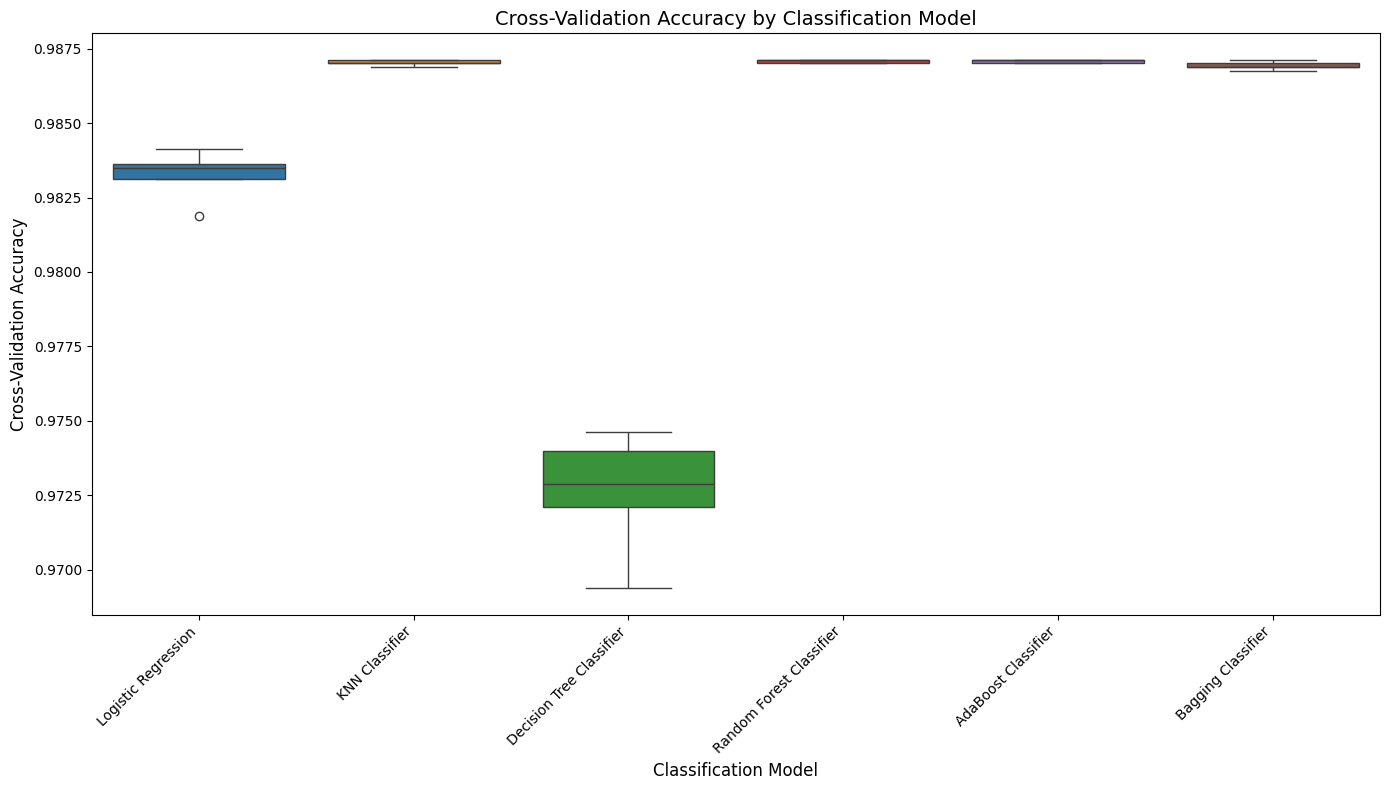

In [48]:
# Plot cross-validation accuracy scores for each classification model

fig, ax = plt.subplots(figsize=(14, 8))

sb.boxplot(data=cv_scores_df, ax=ax)

ax.set_xlabel("Classification Model", fontsize=12)
ax.set_ylabel("Cross-Validation Accuracy", fontsize=12)
ax.set_title("Cross-Validation Accuracy by Classification Model", fontsize=14)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [50]:
y_test.value_counts().sort_index()

claimcount
0    9871
1     127
2       2
Name: count, dtype: int64

In [52]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

classification_models = [
    ("Logistic Regression", LogisticRegression(
        solver="liblinear",
        max_iter=2000,
        class_weight="balanced"
    )),

    ("KNN Classifier", KNeighborsClassifier()),

    ("Decision Tree Classifier", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    )),

    ("Random Forest Classifier", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    )),

    ("Gradient Boosting Classifier", GradientBoostingClassifier(
        random_state=42
    )),

    ("AdaBoost Classifier", AdaBoostClassifier(
        random_state=42,
        algorithm="SAMME"
    )),

    ("Bagging Classifier", BaggingClassifier(
        random_state=42
    )),

    ("XGBoost Classifier", XGBClassifier(
        random_state=42,
        eval_metric="mlogloss"
    )),

    ("CatBoost Classifier", CatBoostClassifier(
        random_state=42,
        verbose=0
    ))
]

In [54]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Apply SMOTE only to the training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Train model on SMOTE-balanced training data
smote_model = RandomForestClassifier(
    random_state=42
)

smote_model.fit(X_train_smote, y_train_smote)

# Predict on original untouched test data
y_pred_test = smote_model.predict(X_test)

print("Model:", smote_model)
print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("\nPrediction counts:")
print(pd.Series(y_pred_test).value_counts().sort_index())

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_test))

print("\nClassification report:")
print(classification_report(y_test, y_pred_test, zero_division=0))

Model: RandomForestClassifier(random_state=42)
Accuracy: 0.9871

Prediction counts:
0    10000
Name: count, dtype: int64

Confusion matrix:
[[9871    0    0]
 [ 127    0    0]
 [   2    0    0]]

Classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      9871
           1       0.00      0.00      0.00       127
           2       0.00      0.00      0.00         2

    accuracy                           0.99     10000
   macro avg       0.33      0.33      0.33     10000
weighted avg       0.97      0.99      0.98     10000



In [57]:
# Optional: predict claim classes for the full dataset
y_pred_all = smote_model.predict(X)

print("Model:", smote_model)

print("\nFull dataset prediction counts:")
print(pd.Series(y_pred_all).value_counts().sort_index())

Model: RandomForestClassifier(random_state=42)

Full dataset prediction counts:
0    49483
1      511
2        6
Name: count, dtype: int64


In [60]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

dummy_model = DummyClassifier(strategy="most_frequent")

dummy_model.fit(X_train, y_train)
y_pred_dummy = dummy_model.predict(X_test)

print("Dummy baseline model: always predicts the most common claim count")

print("\nActual test counts:")
print(y_test.value_counts().sort_index())

print("\nDummy prediction counts:")
print(pd.Series(y_pred_dummy).value_counts().sort_index())

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred_dummy))

print("\nBalanced accuracy:")
print(balanced_accuracy_score(y_test, y_pred_dummy))

print("\nMacro F1:")
print(f1_score(y_test, y_pred_dummy, average="macro", zero_division=0))

Dummy baseline model: always predicts the most common claim count

Actual test counts:
claimcount
0    9871
1     127
2       2
Name: count, dtype: int64

Dummy prediction counts:
0    10000
Name: count, dtype: int64

Accuracy:
0.9871

Balanced accuracy:
0.3333333333333333

Macro F1:
0.3311693758072904


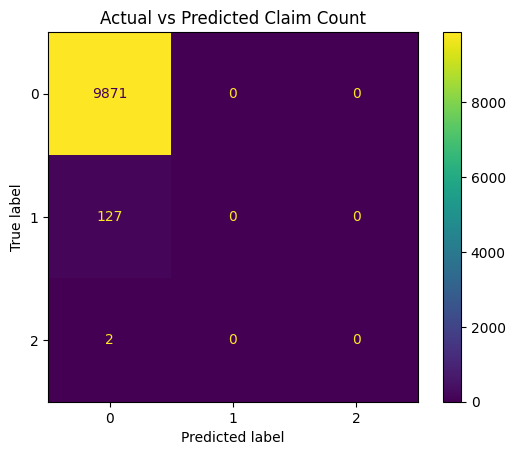

In [61]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test
)

plt.title("Actual vs Predicted Claim Count")
plt.show()

In [62]:
set(y_pred_test)

{np.int64(0)}

In [ ]:
AvP.to_csv('AvP2.csv', index='False')


PermissionError: [Errno 13] Permission denied: 'AvP2.csv'